## Load Data

In [1]:
folder = "Data/Pipe_Alt_717_0/"
#folder = "Data/Air_Target2_717_0/"
#folder = "Data/Air_TargetNoMount_241_0/"

In [2]:
import pickle
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import math

In [3]:
resolution = 0
temp = folder.split("_")
if temp[2] == "717":
    resolution = 0.0352
    if temp[0].split("/")[1] == "Air":
        threshold = 100000
    else:
        threshold = 0.8e6
else:
    resolution = 0.046875
    if temp[0].split("/")[1] == "Air":
        threshold = 300000
    else:
        threshold = 2.0e6
title = f"Measurement in {temp[0].split("/")[1]} using {temp[1]} as target with sensor at {temp[3][-2]}cm offset"
print(resolution)
print(threshold)
print(title)

0.0352
800000.0
Measurement in Pipe using Alt as target with sensor at 0cm offset


In [4]:
dataLin = []
dataLog = []

with open(folder + 'None.pkl', 'rb') as f:
    fileData = pickle.load(f)

fileData = [val[8] for val in fileData]
fileData = [sum(col)/ len(col) for col in zip(*fileData)]

maxRange = len(fileData) * resolution
x = np.linspace(0, maxRange, len(fileData))

dataLin.append([(32.0/float(len(x))) * (2**(val/512.0)) for val in fileData])
dataLog.append([(val*20.0*math.log10(2.0))/512.0 + 20.0*math.log10(32.0/float(len(x))) for val in fileData])

for i in range(5,205,5):
    with open(folder + f'{i}.pkl', 'rb') as f:
        fileData = pickle.load(f)
    fileData = [val[8] for val in fileData]
    fileData = [sum(col)/ len(col) for col in zip(*fileData)]

    dataLin.append([(32.0/float(len(x))) * (2**(val/512.0)) for val in fileData])
    dataLog.append([(val*20.0*math.log10(2.0))/512.0 + 20.0*math.log10(32.0/float(len(x))) for val in fileData])


In [5]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression

In [6]:
measuredPos = []
for i in range(len(dataLin)):
    smoothed = gaussian_filter1d(dataLin[i], sigma=1)
    peaks, properties = find_peaks(smoothed, height=threshold)
    if peaks.size:
        measuredPos.append(x[peaks[0]] * 100.0)
    else:
        print("Not found")
        measuredPos.append(None)

measuredPos = np.array(measuredPos)
actualPos = np.array(range(0,205,5))

Not found
Not found


In [7]:
cleaned = [(x, y) for x, y in zip(actualPos, measuredPos)
           if x is not None and y is not None]

actual_clean, measured_clean = zip(*cleaned)

# Convert to numpy and reshape for sklearn
actual_clean = np.array(actual_clean).reshape(-1, 1)
measured_clean = np.array(measured_clean)

# RANSAC regression
ransac = RANSACRegressor(LinearRegression(), residual_threshold=10.0)
ransac.fit(actual_clean, measured_clean)

# Get slope and intercept
m = ransac.estimator_.coef_[0]
c = ransac.estimator_.intercept_

# Generate line of best fit
lineOBF = m * actualPos + c

inlier_mask = ransac.inlier_mask_
outlier_mask = ~inlier_mask

# Flatten actual_clean back to 1D for easier indexing
actual_clean_flat = actual_clean.flatten()

# Get inliers
actual_inliers = actual_clean_flat[inlier_mask]
measured_inliers = measured_clean[inlier_mask]

# Get outliers
actual_outliers = actual_clean_flat[outlier_mask]
measured_outliers = measured_clean[outlier_mask]


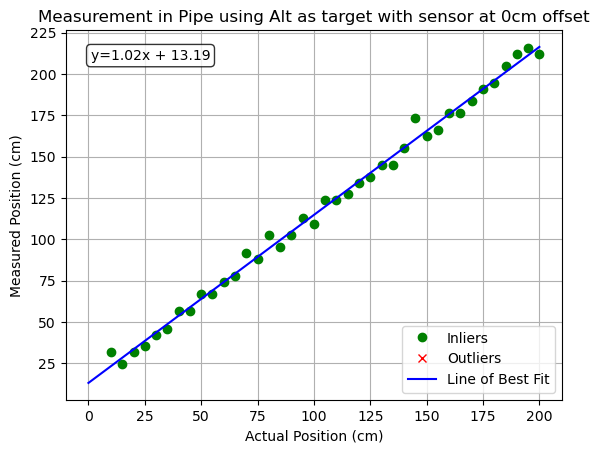

In [8]:
#plt.plot(actualPos, measuredPos, "ro", label="Measured Peaks")
plt.plot(actual_inliers, measured_inliers, "go", label="Inliers")
plt.plot(actual_outliers, measured_outliers,"rx", label="Outliers")
plt.plot(actualPos, lineOBF, "b-", label="Line of Best Fit")
plt.xlabel("Actual Position (cm)")
plt.ylabel("Measured Position (cm)")
plt.legend()
plt.text(
    0.05, 0.95, f"y={m:.2f}x + {c:.2f}",
    transform=plt.gca().transAxes,   # use axis coordinates (0–1)
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
plt.grid()
plt.title(title)
plt.show()

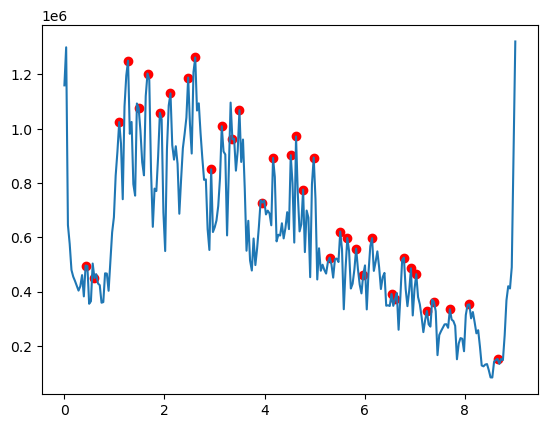

In [9]:
i = 20
smoothed = gaussian_filter1d(dataLin[i], sigma=1)
peaks, properties = find_peaks(smoothed, height=100000)

plt.plot([x[val] for val in peaks], [dataLin[i][val] for val in peaks], "ro")
plt.plot(x, dataLin[i])
plt.show()